In [26]:
import torch
import torchvision
from torchvision import datasets, models, transforms
import torch.nn as nn
import torch.optim as optim
import time
import os
from copy import copy
from copy import deepcopy
import torch.nn.functional as F
import zipfile
import os
import requests
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [2]:
class BasicBlock(nn.Module):
    '''
    BasicBlock: Simple residual block with two conv layers
    '''
    EXPANSION = 1
    def __init__(self, in_planes, out_planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_planes)
        self.conv2 = nn.Conv2d(out_planes, out_planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_planes)
        self.shortcut = nn.Sequential()
        # If output size is not equal to input size, reshape it with 1x1 convolution
        if stride != 1 or in_planes != out_planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

In [3]:
class BottleneckBlock(nn.Module):
    '''
    BottleneckBlock: More powerful residual block with three convs, used for Resnet50 and up
    '''
    EXPANSION = 4
    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(planes, self.EXPANSION * planes, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(self.EXPANSION * planes)

        self.shortcut = nn.Sequential()
        # If the output size is not equal to input size, reshape it with 1x1 convolution
        if stride != 1 or in_planes != self.EXPANSION * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.EXPANSION * planes,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.EXPANSION * planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

In [4]:
class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super().__init__()
        self.in_planes = 64
        # Initial convolution
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        # Residual blocks
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        # FC layer = 1 layer
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.linear = nn.Linear(512 * block.EXPANSION, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.EXPANSION
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out

In [5]:
def ResNet18(num_classes = 10):
    '''
    First conv layer: 1
    4 residual blocks with two sets of two convolutions each: 2*2 + 2*2 + 2*2 + 2*2 = 16 conv layers
    last FC layer: 1
    Total layers: 1+16+1 = 18
    '''
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes)


def ResNet34(num_classes):
    '''
    First conv layer: 1
    4 residual blocks with [3, 4, 6, 3] sets of two convolutions each: 3*2 + 4*2 + 6*2 + 3*2 = 32
    last FC layer: 1
    Total layers: 1+32+1 = 34
    '''
    return ResNet(BasicBlock, [3, 4, 6, 3], num_classes)


def ResNet50(num_classes = 10):
    '''
    First conv layer: 1
    4 residual blocks with [3, 4, 6, 3] sets of three convolutions each: 3*3 + 4*3 + 6*3 + 3*3 = 48
    last FC layer: 1
    Total layers: 1+48+1 = 50
    '''
    return ResNet(Bottleneck, [3, 4, 6, 3], num_classes)


def ResNet101(num_classes = 10):
    '''
    First conv layer: 1
    4 residual blocks with [3, 4, 23, 3] sets of three convolutions each: 3*3 + 4*3 + 23*3 + 3*3 = 99
    last FC layer: 1
    Total layers: 1+99+1 = 101
    '''
    return ResNet(Bottleneck, [3, 4, 23, 3], num_classes)


def ResNet152(num_classes = 10):
    '''
    First conv layer: 1
    4 residual blocks with [3, 8, 36, 3] sets of three convolutions each: 3*3 + 8*3 + 36*3 + 3*3 = 150
    last FC layer: 1
    Total layers: 1+150+1 = 152
    '''
    return ResNet(Bottleneck, [3, 8, 36, 3], num_classes)

In [6]:
# device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
device_index = 2 
if torch.cuda.device_count() > device_index:
    device = torch.device(f"cuda:{device_index}")
else:
    device = torch.device("cpu")

In [7]:
class SELayer(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

In [8]:
class ResidualSEBasicBlock(nn.Module):
    '''
    ResidualSEBasicBlock: Standard two-convolution residual block with an SE Module between the
                          second convolution and the identity addition
    '''
    EXPANSION = 1

    def __init__(self, in_planes, out_planes, stride=1, reduction=16):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_planes)
        self.conv2 = nn.Conv2d(out_planes, out_planes, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_planes)
        self.se = SELayer(out_planes, reduction)

        self.shortcut = nn.Sequential()
        # If output size is not equal to input size, reshape it with a 1x1 conv
        if stride != 1 or in_planes != out_planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, out_planes,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.EXPANSION * out_planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)              # se net add here
        out += self.shortcut(x)         # shortcut just plus it!!!
        out = F.relu(out)
        return out


def ResSENet18_SE(num_classes = 10):
    return ResNet(ResidualSEBasicBlock, [2, 2, 2, 2], num_classes)

In [9]:
def to_float_list(seq):
    result = []
    for item in seq:
        if hasattr(item, "detach"):  # Case 1: Tensor
            result.append(item.detach().cpu().numpy().item()
                          if item.numel() == 1
                          else float(item.mean().cpu().numpy()))
        elif callable(item):         # Case 2: Method or function
            result.append(np.nan)
        else:                        # Case 3: Already float/int
            result.append(float(item))
    return result

In [10]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs=25, weights_name='weight_save', is_inception=False):
    '''
    train_model: train a model on a dataset

            Parameters:
                    model: Pytorch model
                    dataloaders: dataset
                    criterion: loss function
                    optimizer: update weights function
                    num_epochs: number of epochs
                    weights_name: file name to save weights
                    is_inception: The model is inception net (Google LeNet) or not

            Returns:
                    model: Best model from evaluation result
                    train_losses: training loss history
                    val_losses: validation loss history
                    train_accs: training accuracy history
                    val_accs: validation accuracy history
    '''
    since = time.time()

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    best_model_wts = deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        epoch_start = time.time()

        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for batch in dataloaders[phase]:
                if isinstance(batch, dict):
                    inputs = batch['image']
                    labels = batch['label']
                else:
                    inputs, labels = batch


                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    if is_inception and phase == 'train':
                        outputs, aux_outputs = model(inputs)
                        loss1 = criterion(outputs, labels)
                        loss2 = criterion(aux_outputs, labels)
                        loss = loss1 + 0.4 * loss2
                    else:
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)

                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)
            epoch_end = time.time()

            elapsed_epoch = epoch_end - epoch_start

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))
            print("Epoch time taken: ", elapsed_epoch)

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = deepcopy(model.state_dict())
                torch.save(model.state_dict(), weights_name + ".pth")

            if phase == 'train':
                train_losses.append(epoch_loss)
                train_accs.append(epoch_acc)
            else:
                val_losses.append(epoch_loss)
                val_accs.append(epoch_acc)

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    model.load_state_dict(best_model_wts)
    return model, train_losses, val_losses, train_accs, val_accs

In [11]:
def plot_curves(train_acc, val_acc, train_loss, val_loss, title):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(5,4))
    plt.plot(train_loss, label='Train Loss')
    plt.plot(val_loss, label='Val Loss')
    plt.legend(); plt.title(f'{title} Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(True, alpha=0.3); plt.show()
    plt.figure(figsize=(5,4))
    plt.plot(train_acc, label='Train Acc')
    plt.plot(val_acc, label='Val Acc')
    plt.legend(); plt.title(f'{title} Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.grid(True, alpha=0.3); plt.show()


## CIFAR 10 Dataset

In [34]:
train_preprocess = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.49139968, 0.48215827, 0.44653124), (0.24703233, 0.24348505, 0.26158768))])

eval_preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.49139968, 0.48215827, 0.44653124), (0.24703233, 0.24348505, 0.26158768))])

# Download CIFAR-10 and split into training, validation, and test sets.
# The copy of the training dataset after the split allows us to keep
# the same training/validation split of the original training set but
# apply different transforms to the training set and validation set.

full_train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                                  download=True)

train_dataset, val_dataset = torch.utils.data.random_split(full_train_dataset, [40000, 10000])
train_dataset.dataset = copy(full_train_dataset)
train_dataset.dataset.transform = train_preprocess
val_dataset.dataset.transform = eval_preprocess

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                            download=True, transform=eval_preprocess)

# DataLoaders for the three datasets

BATCH_SIZE=128
NUM_WORKERS=4

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE,
                                            shuffle=True, num_workers=NUM_WORKERS)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE,
                                            shuffle=False, num_workers=NUM_WORKERS)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE,
                                            shuffle=False, num_workers=NUM_WORKERS)

dataloaders = {'train': train_dataloader, 'val': val_dataloader}

In [36]:
resnet = ResNet18().to(device)
# Optimizer and loss function
criterion = nn.CrossEntropyLoss()
params_to_update = resnet.parameters()
# Now we'll use Adam optimization
optimizer = optim.Adam(params_to_update, lr=0.01)

best_model, train_losses, val_losses, train_accs, val_accs = train_model(resnet, dataloaders, criterion, optimizer, 25, 'resnet18_bestsofar')

Epoch 0/24
----------
train Loss: 1.8231 Acc: 0.3368
Epoch time taken:  13.97463607788086
val Loss: 1.5754 Acc: 0.4226
Epoch time taken:  15.288867235183716

Epoch 1/24
----------
train Loss: 1.3002 Acc: 0.5267
Epoch time taken:  14.046583890914917
val Loss: 1.2467 Acc: 0.5501
Epoch time taken:  15.403651475906372

Epoch 2/24
----------
train Loss: 1.0196 Acc: 0.6341
Epoch time taken:  14.18627405166626
val Loss: 0.8900 Acc: 0.6788
Epoch time taken:  15.564897060394287

Epoch 3/24
----------
train Loss: 0.8283 Acc: 0.7068
Epoch time taken:  14.20264458656311
val Loss: 0.8848 Acc: 0.6865
Epoch time taken:  15.541638135910034

Epoch 4/24
----------
train Loss: 0.6709 Acc: 0.7625
Epoch time taken:  14.216882944107056
val Loss: 0.8452 Acc: 0.7260
Epoch time taken:  15.59026288986206

Epoch 5/24
----------
train Loss: 0.5532 Acc: 0.8060
Epoch time taken:  14.301340341567993
val Loss: 0.6171 Acc: 0.7887
Epoch time taken:  15.68303394317627

Epoch 6/24
----------
train Loss: 0.4617 Acc: 0.838

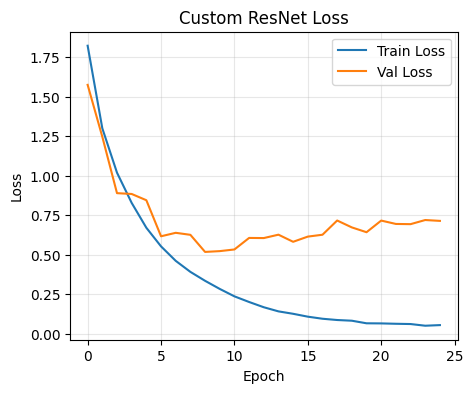

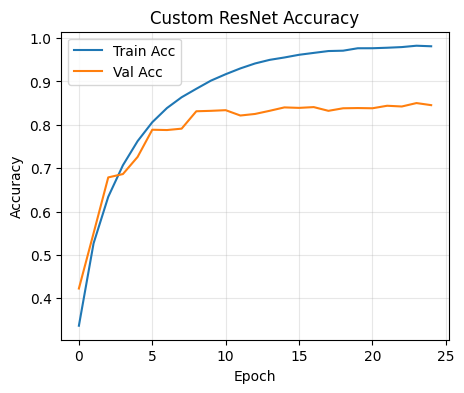

In [41]:
train_accs=to_float_list(train_accs)
val_accs=to_float_list(val_accs)
train_losses=to_float_list(train_losses)
val_losses=to_float_list(val_losses)
plot_curves(train_accs, val_accs, train_losses, val_losses, "Custom ResNet")
 

## Kaprao-Horapa Dataset

In [15]:
from torch.utils.data import Dataset, DataLoader
from os import listdir
from PIL import Image


class BasilDataset(Dataset):
    def __init__(self, root_path="vege_dataset/", transform=None):
        # keep root directory
        self.dir = root_path
        # keep transform
        self.transform = transform

        # read all files in kapao and horapa folder
        list_kaprao = listdir(root_path + 'kapao/')
        list_horapa = listdir(root_path + 'horapa/')
        # calculate all number for each class (just in case)
        self.kaprao_len = len(list_kaprao)
        self.horapa_len = len(list_horapa)

        # put the data file path into ids
        self.ids = [self.dir + 'kapao/' + file for file in list_kaprao if not file.startswith('.')]
        self.ids.extend([self.dir + 'horapa/' + file for file in list_horapa if not file.startswith('.')])
        
    def __len__(self):
        # return self.kaprao_len + self.horapa_len
        return len(self.ids)


    
    def __getitem__(self, i):
        idx = self.ids[i]
        img_file = idx
        
        # open photo
        pil_img = Image.open(img_file)
        
        # resize, normalize and convert to pytorch tensor
        if self.transform:
            img = self.transform(pil_img)
        self.pil_img = pil_img
            
        # get label from file list counter
        if i < self.kaprao_len:
            label = 0
        else:
            label = 1
            
        return {
            'image': img,
            'label': label,
            'file_name' : img_file,
        }

In [16]:
url = "https://www.dropbox.com/scl/fi/uibcd2grj4ytzrrqyhe6m/vege_dataset.zip?rlkey=mnh861750qb3jhenvxe4l77c5&e=1&dl=1"
zip_path = "vege_dataset.zip"
dataset_root = Path("vege_dataset")

if not dataset_root.exists():
    print("📥 Downloading dataset from Dropbox...")
    r = requests.get(url)
    with open(zip_path, "wb") as f:
        f.write(r.content)

    print("📦 Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("✅ Extraction complete.")

else:
    print("✅ Dataset already available at:", dataset_root)

✅ Dataset already available at: vege_dataset


In [17]:
root = "vege_dataset/"

transform = transforms.Compose([
    transforms.Resize(32),
    transforms.RandomCrop(28), # CenterCrop
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

dataset = BasilDataset(root, transform)

kaprao
vege_dataset/kapao/20220425_213928_resize.jpg


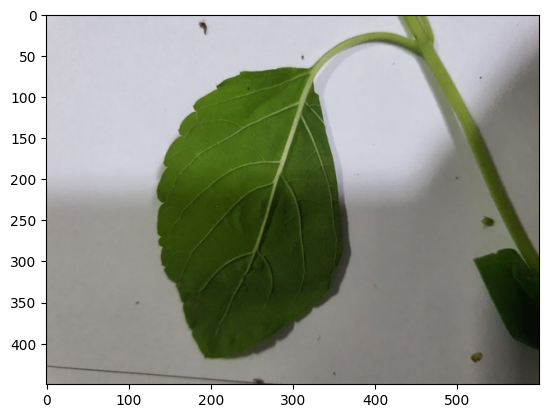

In [18]:
import matplotlib.pyplot as plt

output_label = ['kaprao', 'horapa']

batch = dataset[0]
image, label, filename = batch['image'], batch['label'], batch['file_name']
pil_img = Image.open(filename)

print(output_label[label])
print(filename)
# (3, 224, 224) pytorch
# pyplot -> (224,224,3)
plt.imshow(pil_img)
plt.show()

In [19]:
train_loader = DataLoader(dataset, batch_size=64, shuffle=True, pin_memory=True)

In [21]:
resnet = ResNet18(2).to(device)
# Optimizer and loss function
criterion = nn.CrossEntropyLoss()
params_to_update = resnet.parameters()
# Now we'll use Adam optimization
optimizer = optim.Adam(params_to_update, lr=0.01)

In [23]:
n_epochs = 25

loss_history = []
loss_history_epoch = []
accuracy = []

for epoch in range(1, n_epochs + 1):
    epoch_iter = 0                  # the number of training iterations in current epoch, reset to 0 every epoch
    running_loss = 0
    running_corrects = 0
    for batch in train_loader:
        image, label, filename = batch['image'], batch['label'], batch['file_name']
            
        epoch_iter += image.shape[0]

        image = image.to(device)
        label = label.to(device)

        # training only
        optimizer.zero_grad()

        output = resnet(image)

        # 0, 1, 0, 0 ---> 0.2, 0.6, 0.1, 0.1
        loss = criterion(output, label)       # training

        # prediction - real use
        _, preds = torch.max(output, 1)

        running_loss += loss.item() * image.size(0)
        running_corrects += torch.sum(preds == label.data)

        loss.backward()       # back propagation -> calculate that how much value to update weight
        optimizer.step()      #update weight

        loss_history.append(loss.item() * image.size(0))
        if (epoch_iter % 640 == 0):
            print('{} Loss: {:.4f} Acc: {:.4f}'.format(epoch_iter, loss.item(), running_corrects / epoch_iter))
        
    loss_history_epoch.append(running_loss / epoch_iter)
    accuracy.append(running_corrects / epoch_iter)

    print('Epoch: {} Loss: {:.4f} Acc: {:.4f}'.format(epoch, running_loss / epoch_iter, running_corrects / epoch_iter * 100.0))

640 Loss: 0.7635 Acc: 0.5266
1280 Loss: 0.6168 Acc: 0.6305
Epoch: 1 Loss: 1.0466 Acc: 64.6341
640 Loss: 0.2521 Acc: 0.8438
1280 Loss: 0.3446 Acc: 0.8539
Epoch: 2 Loss: 0.3333 Acc: 85.7245
640 Loss: 0.3273 Acc: 0.8578
1280 Loss: 0.2225 Acc: 0.8734
Epoch: 3 Loss: 0.2985 Acc: 87.3027
640 Loss: 0.5685 Acc: 0.8984
1280 Loss: 0.2234 Acc: 0.8922
Epoch: 4 Loss: 0.2708 Acc: 88.7374
640 Loss: 0.2712 Acc: 0.9000
1280 Loss: 0.1766 Acc: 0.9000
Epoch: 5 Loss: 0.2403 Acc: 89.9570
640 Loss: 0.1977 Acc: 0.8875
1280 Loss: 0.1896 Acc: 0.9070
Epoch: 6 Loss: 0.2312 Acc: 90.6026
640 Loss: 0.2184 Acc: 0.9094
1280 Loss: 0.0809 Acc: 0.9156
Epoch: 7 Loss: 0.2201 Acc: 91.3917
640 Loss: 0.1716 Acc: 0.9281
1280 Loss: 0.3467 Acc: 0.9195
Epoch: 8 Loss: 0.2187 Acc: 91.6786
640 Loss: 0.0954 Acc: 0.9094
1280 Loss: 0.3729 Acc: 0.9094
Epoch: 9 Loss: 0.2110 Acc: 90.8178
640 Loss: 0.3103 Acc: 0.8953
1280 Loss: 0.2271 Acc: 0.9102
Epoch: 10 Loss: 0.2301 Acc: 91.2482
640 Loss: 0.1765 Acc: 0.9391
1280 Loss: 0.3064 Acc: 0.9305


## Exercise 1

In [24]:
import torch
from torch.utils.data import Subset

# Set seed for reproducibility
torch.manual_seed(42)

# Shuffle indices
total_size = len(dataset)
indices = torch.randperm(total_size).tolist()

# Split indices
split = int(0.9 * total_size)
train_indices = indices[:split]
val_indices = indices[split:]

# Create subsets
train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)

In [25]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
ex1_dataloaders = {'train': train_loader, 'val': val_loader}

In [26]:
resnet = ResNet18().to(device)
# Optimizer and loss function
criterion = nn.CrossEntropyLoss()
params_to_update = resnet.parameters()
# Now we'll use Adam optimization
optimizer = optim.Adam(params_to_update, lr=0.01)

best_model, train_losses, val_losses, train_accs, val_accs = train_model(resnet, ex1_dataloaders, criterion, optimizer, 25, 'resnet18_bestsofar')

Epoch 0/24
----------
train Loss: 0.8250 Acc: 0.6651
Epoch time taken:  4.480274200439453
val Loss: 0.5985 Acc: 0.8429
Epoch time taken:  4.943864822387695

Epoch 1/24
----------
train Loss: 0.5265 Acc: 0.7935
Epoch time taken:  4.444201707839966
val Loss: 0.5173 Acc: 0.7786
Epoch time taken:  4.877918481826782

Epoch 2/24
----------
train Loss: 0.3930 Acc: 0.8341
Epoch time taken:  4.422317266464233
val Loss: 0.2954 Acc: 0.8571
Epoch time taken:  4.862434387207031

Epoch 3/24
----------
train Loss: 0.3360 Acc: 0.8541
Epoch time taken:  4.495402097702026
val Loss: 0.6214 Acc: 0.7500
Epoch time taken:  4.935179948806763

Epoch 4/24
----------
train Loss: 0.2537 Acc: 0.8963
Epoch time taken:  4.384491682052612
val Loss: 0.2064 Acc: 0.9286
Epoch time taken:  4.8294689655303955

Epoch 5/24
----------
train Loss: 0.2674 Acc: 0.8907
Epoch time taken:  4.465078353881836
val Loss: 0.5133 Acc: 0.8143
Epoch time taken:  4.899507284164429

Epoch 6/24
----------
train Loss: 0.2528 Acc: 0.9003
Epoc

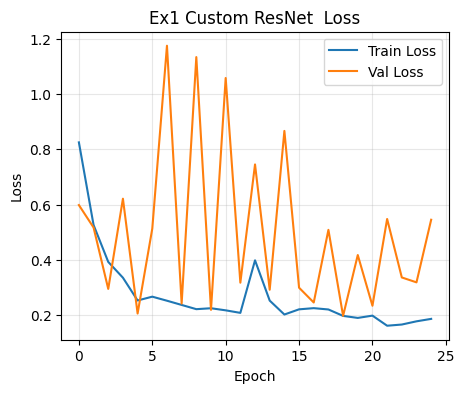

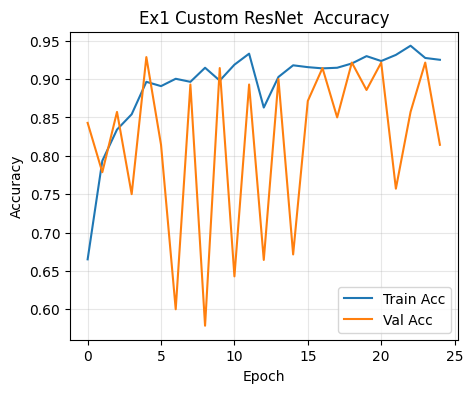

In [27]:
train_accs=to_float_list(train_accs)
val_accs=to_float_list(val_accs)
train_losses=to_float_list(train_losses)
val_losses=to_float_list(val_losses)
plot_curves(train_accs, val_accs, train_losses, val_losses, "Ex1 Custom ResNet ")

## Exercise 2

In [12]:
class InceptionSEBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        if out_channels % 4 != 0:
            raise ValueError(f"out_channels ({out_channels}) must be divisible by 4")

        branch_channels = out_channels // 4

        self.branch1 = nn.Conv2d(in_channels, branch_channels, kernel_size=1)

        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, branch_channels, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(branch_channels, branch_channels, kernel_size=3, padding=1)
        )

        self.branch5 = nn.Sequential(
            nn.Conv2d(in_channels, branch_channels, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(branch_channels, branch_channels, kernel_size=5, padding=2)
        )

        self.pool_branch = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, branch_channels, kernel_size=1)
        )

        self.se = SELayer(out_channels)

    def forward(self, x):
        b1 = self.branch1(x)
        b3 = self.branch3(x)
        b5 = self.branch5(x)
        bp = self.pool_branch(x)

        out = torch.cat([b1, b3, b5, bp], dim=1)
        out = self.se(out)
        return out

In [13]:
class InceptionSENet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.block1 = InceptionSEBlock(64, 128)
        self.block2 = InceptionSEBlock(128, 256)
        self.block3 = InceptionSEBlock(256, 256)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.pool(x).view(x.size(0), -1)
        return self.fc(x)

In [19]:
train_preprocess = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.49139968, 0.48215827, 0.44653124), (0.24703233, 0.24348505, 0.26158768))])

eval_preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.49139968, 0.48215827, 0.44653124), (0.24703233, 0.24348505, 0.26158768))])

# Download CIFAR-10 and split into training, validation, and test sets.
# The copy of the training dataset after the split allows us to keep
# the same training/validation split of the original training set but
# apply different transforms to the training set and validation set.

full_train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                                  download=True)

train_dataset, val_dataset = torch.utils.data.random_split(full_train_dataset, [40000, 10000])
train_dataset.dataset = copy(full_train_dataset)
train_dataset.dataset.transform = train_preprocess
val_dataset.dataset.transform = eval_preprocess

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                            download=True, transform=eval_preprocess)

# DataLoaders for the three datasets

BATCH_SIZE=128
NUM_WORKERS=4

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE,
                                            shuffle=True, num_workers=NUM_WORKERS)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE,
                                            shuffle=False, num_workers=NUM_WORKERS)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE,
                                            shuffle=False, num_workers=NUM_WORKERS)

dataloaders = {'train': train_dataloader, 'val': val_dataloader}

In [21]:
inceptse_model = InceptionSENet(num_classes=10).to(device)
params_to_update = inceptse_model.parameters()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params_to_update, lr=0.001)

model, train_losses, val_losses, train_accs, val_accs = train_model(
    inceptse_model, dataloaders, criterion, optimizer,
    num_epochs=25,
    weights_name='inception_se_cifar10',
    is_inception=False
)

Epoch 0/24
----------
train Loss: 1.7943 Acc: 0.3122
Epoch time taken:  19.345677375793457
val Loss: 1.5892 Acc: 0.4013
Epoch time taken:  21.05475616455078

Epoch 1/24
----------
train Loss: 1.5029 Acc: 0.4387
Epoch time taken:  19.37024164199829
val Loss: 1.4123 Acc: 0.4820
Epoch time taken:  21.04000186920166

Epoch 2/24
----------
train Loss: 1.2976 Acc: 0.5245
Epoch time taken:  19.959463596343994
val Loss: 1.1992 Acc: 0.5644
Epoch time taken:  21.703158855438232

Epoch 3/24
----------
train Loss: 1.1711 Acc: 0.5720
Epoch time taken:  20.547998905181885
val Loss: 1.1325 Acc: 0.5974
Epoch time taken:  22.34153389930725

Epoch 4/24
----------
train Loss: 1.0838 Acc: 0.6037
Epoch time taken:  20.39380931854248
val Loss: 1.0496 Acc: 0.6179
Epoch time taken:  22.161308765411377

Epoch 5/24
----------
train Loss: 1.0195 Acc: 0.6303
Epoch time taken:  20.365654945373535
val Loss: 0.9811 Acc: 0.6413
Epoch time taken:  22.21278405189514

Epoch 6/24
----------
train Loss: 0.9624 Acc: 0.6520

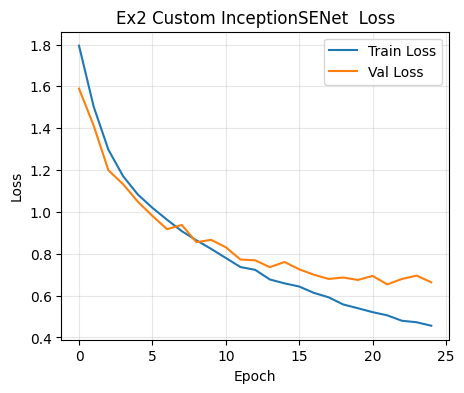

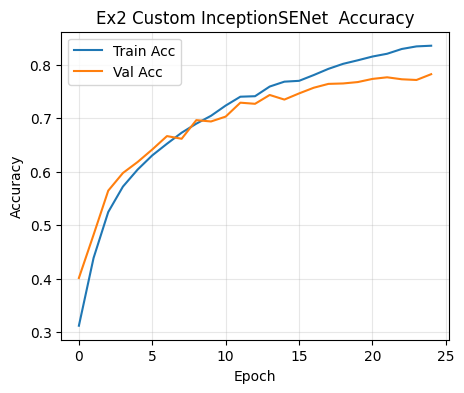

In [22]:
train_accs=to_float_list(train_accs)
val_accs=to_float_list(val_accs)
train_losses=to_float_list(train_losses)
val_losses=to_float_list(val_losses)
plot_curves(train_accs, val_accs, train_losses, val_losses, "Ex2 Custom InceptionSENet ")

## Exercise 3

In [11]:
!mkdir -p TrashClassification

# Download the dataset ZIP directly using curl
!curl -L -o TrashClassification/finaldata.zip \
  https://www.kaggle.com/api/v1/datasets/download/surabhisathish/finaldata




  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  103M  100  103M    0     0  9320k      0  0:00:11  0:00:11 --:--:-- 11.0M


In [12]:
import zipfile, os

zip_path = "TrashClassification/finaldata.zip"
extract_path = "TrashClassification"

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted to:", extract_path)
else:
    print("ZIP file not found.")


Dataset extracted to: TrashClassification


In [14]:
base_dir = "TrashClassification/rubbish-data"

train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

In [15]:
mean = (0.485, 0.456, 0.406)   
std  = (0.229, 0.224, 0.225)  

train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),    
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

val_test_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

In [16]:
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_tfms)
val_dataset   = datasets.ImageFolder(root=val_dir,   transform=val_test_tfms)
test_dataset  = datasets.ImageFolder(root=test_dir,  transform=val_test_tfms)

print(f" Train size: {len(train_dataset)} | Val size: {len(val_dataset)} | Test size: {len(test_dataset)}")
print(f" Number of classes: {len(train_dataset.classes)}")
print(f"Classes: {train_dataset.classes}")

 Train size: 7975 | Val size: 1050 | Test size: 1113
 Number of classes: 10
Classes: ['battery', 'biological', 'brown-glass', 'cardboard', 'green-glass', 'metal', 'paper', 'plastic', 'trash', 'white-glass']


In [19]:
BATCH_SIZE = 16
NUM_WORKERS = 2 

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

dataloaders = {'train': train_loader, 'val': val_loader}


In [20]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


def train_model2(model, dataloaders, criterion, optimizer, num_epochs=25, weights_name='weight_save', is_inception=False):
    import torch
    import time
    from copy import deepcopy
    from torch.cuda.amp import autocast, GradScaler
    

    since = time.time()
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    best_model_wts = deepcopy(model.state_dict())
    best_acc = 0.0
    scaler = GradScaler()  # For mixed precision

    for epoch in range(num_epochs):
        epoch_start = time.time()
        print(f'Epoch {epoch}/{num_epochs - 1}\n{"-" * 10}')

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()
            running_loss = 0.0
            running_corrects = 0

            for batch in dataloaders[phase]:
                if isinstance(batch, dict):
                    inputs = batch['image']
                    labels = batch['label']
                else:
                    inputs, labels = batch

                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    with autocast():  # Mixed precision
                        if is_inception and phase == 'train':
                            outputs, aux_outputs = model(inputs)
                            loss1 = criterion(outputs, labels)
                            loss2 = criterion(aux_outputs, labels)
                            loss = loss1 + 0.4 * loss2
                        else:
                            outputs = model(inputs)
                            loss = criterion(outputs, labels)

                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        scaler.scale(loss).backward()
                        scaler.step(optimizer)
                        scaler.update()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                # Free memory
                del inputs, labels, outputs, preds, loss
                torch.cuda.empty_cache()

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)
            elapsed_epoch = time.time() - epoch_start

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            print("Epoch time taken:", elapsed_epoch)

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = deepcopy(model.state_dict())
                torch.save(model.state_dict(), weights_name + ".pth")

            if phase == 'train':
                train_losses.append(epoch_loss)
                train_accs.append(epoch_acc)
            else:
                val_losses.append(epoch_loss)
                val_accs.append(epoch_acc)

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model, train_losses, val_losses, train_accs, val_accs

In [21]:
inceptse_model = InceptionSENet(num_classes=10).to(device)
params_to_update = inceptse_model.parameters()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params_to_update, lr=0.001)

model, train_losses, val_losses, train_accs, val_accs = train_model2(
    inceptse_model, dataloaders, criterion, optimizer,
    num_epochs=25,
    weights_name='inception_se_cifar10',
    is_inception=False
)

Epoch 0/24
----------
train Loss: 1.6303 Acc: 0.4193
Epoch time taken: 147.5932013988495
val Loss: 1.2111 Acc: 0.5714
Epoch time taken: 153.2510974407196

Epoch 1/24
----------
train Loss: 1.2702 Acc: 0.5564
Epoch time taken: 150.75545263290405
val Loss: 1.0622 Acc: 0.6276
Epoch time taken: 156.4108748435974

Epoch 2/24
----------
train Loss: 1.1400 Acc: 0.6063
Epoch time taken: 151.3446900844574
val Loss: 0.9941 Acc: 0.6410
Epoch time taken: 157.00489115715027

Epoch 3/24
----------
train Loss: 1.0646 Acc: 0.6290
Epoch time taken: 151.046972990036
val Loss: 0.9552 Acc: 0.6590
Epoch time taken: 156.7180736064911

Epoch 4/24
----------
train Loss: 1.0142 Acc: 0.6475
Epoch time taken: 150.5428910255432
val Loss: 0.9395 Acc: 0.6790
Epoch time taken: 156.22001814842224

Epoch 5/24
----------
train Loss: 0.9625 Acc: 0.6692
Epoch time taken: 150.26923966407776
val Loss: 0.8971 Acc: 0.6962
Epoch time taken: 155.8871512413025

Epoch 6/24
----------
train Loss: 0.9202 Acc: 0.6750
Epoch time tak

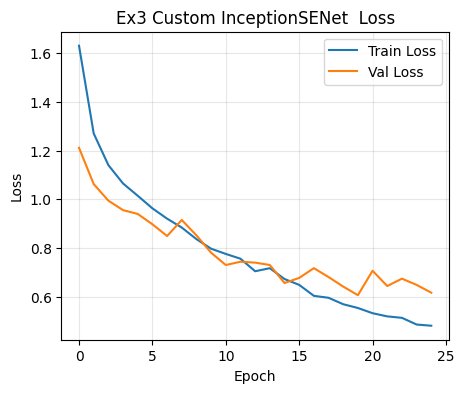

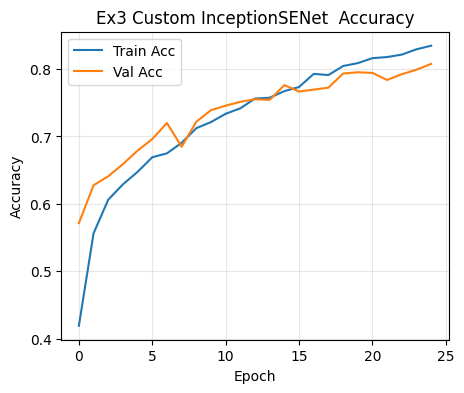

In [23]:
train_accs=to_float_list(train_accs)
val_accs=to_float_list(val_accs)
train_losses=to_float_list(train_losses)
val_losses=to_float_list(val_losses)

plot_curves(train_accs, val_accs, train_losses, val_losses, "Ex3 Custom InceptionSENet ")

In [27]:

def show_predictions(model, dataloader, class_names, device, num_images=6):
    """
    Display sample predictions with image and labels.

    Args:
        model: trained model (in eval mode)
        dataloader: DataLoader (e.g. test_loader)
        class_names: list of class names (dataset.classes)
        device: torch.device('cuda' or 'cpu')
        num_images: number of images to display
    """
    model.eval()
    images_shown = 0
    plt.figure(figsize=(14, 8))

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            for j in range(images.size(0)):
                images_shown += 1
                ax = plt.subplot(num_images//3 + 1, 3, images_shown)
                ax.axis('off')

                # Denormalize for display
                img = images[j].cpu().permute(1, 2, 0).numpy()
                mean = [0.485, 0.456, 0.406]
                std = [0.229, 0.224, 0.225]
                img = std * img + mean
                img = torch.clip(torch.tensor(img), 0, 1).numpy()

                ax.imshow(img)
                true_label = class_names[labels[j].item()]
                pred_label = class_names[preds[j].item()]

                color = "green" if pred_label == true_label else "red"
                ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)

                if images_shown == num_images:
                    plt.tight_layout()
                    plt.show()
                    return

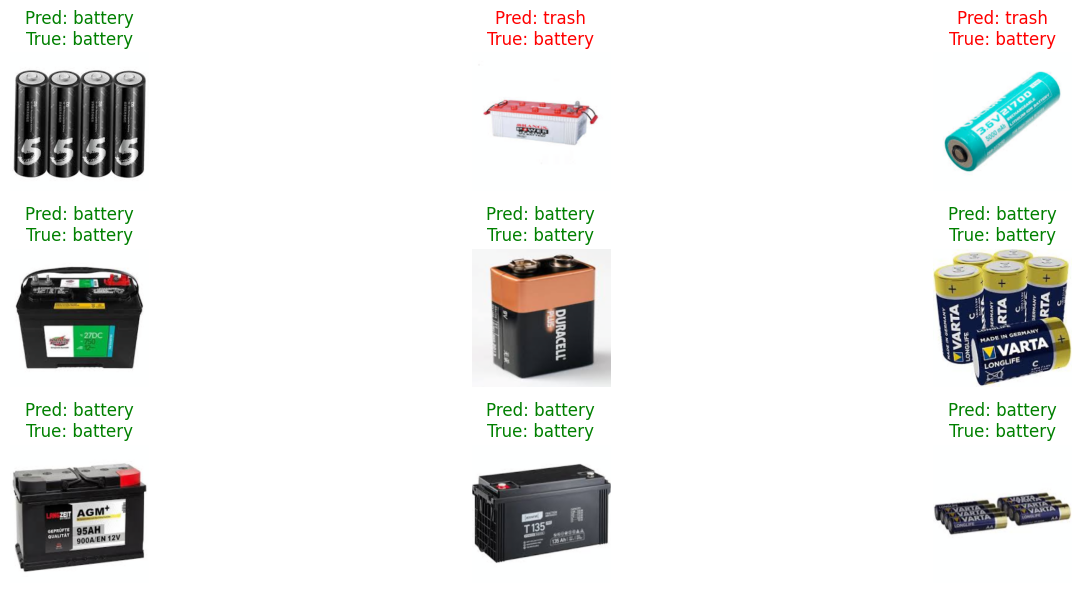

In [28]:
show_predictions(model=inceptse_model,
                 dataloader=test_loader,
                 class_names=train_dataset.classes,
                 device=device,
                 num_images=9)